In [10]:
import pandas as pd 
import numpy as np
import os 
import xarray as xr 
import matplotlib.pyplot as plt
import cmocean as cmo 
import pandas as pd 

import numpy as np
import matplotlib.dates as mdates
import cmcrameri.cm as cmc

# Start date 
start_date = '2024-08-06'
end_date = '2024-08-28' 

Dates = pd.date_range(start_date, end_date, freq='10s')

import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

def format_date_ax(ax):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

chla2cell_mc =  1e-6/0.36  # ug chl-a/ml --> pg chl-a/ml --> 0.36  pg chl-a/cell Microcystis
chla2cell_diatom = 1e-6/4 # ug chl-a/ml --> pg chl-a/ml --> 4 pg chl-a/cell Diatom
cell2chla_mc = 1/chla2cell_mc
cell2chla_diatom = 1/chla2cell_diatom

In [12]:

temp = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/turbulence-model/data/forcing_data/data/Temperature_processed.csv")
temp = temp.loc[temp.SITE == "WEB"]
temp = temp.loc[temp.STAT == "Average"]
temp.reset_index(inplace=True)
temp['time'] = pd.to_datetime(temp['TIMESTAMP'])
temp.drop(columns=['STAT', 'SITE', "SENSOR", "Interval", "TIMESTAMP"], inplace=True)
temp['day'] = temp['time'].dt.day

def get_dwl(day, time, T0):
    temp0 = temp.loc[temp.day == day]
    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)
    kernel2 = np.ones(4)/4
    averaged_md = np.convolve(md, kernel2, mode='same')

    mask = maxs>T0
    mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])
    if sum(mask)>2:
        difference = (pd.to_datetime(X[mask][-1]) - pd.to_datetime(X[mask][-2])) 
        if difference  > pd.Timedelta(hours=1):
            # print("Warning: gap in DWL detection larger than 1 hour on day %d" % day)
            mask[np.where(X==X[mask][-1])[0][0]] = False

    return X, averaged_md, mask


In [11]:
days = range(6, 28)

days_fn = ["august_%02d" % day for day in days]
print(days_fn)

guess = {} 

# get list of files in finished/
read_in = os.listdir('finished/')
print(read_in)

import re

for file in read_in:
    if file.startswith('forward_1_') or file.startswith('adjoint'):
        pass
    else:
        # print(file)
        match = re.search(r'(\d+)(?=\.nc$)', file)
        day = match.group(1)
        guess[day] = xr.open_dataset('finished/%s' % (file), decode_timedelta=False)
        print("Opened day ", day)
        z = guess[day].z.values

    # Get last two digits 

# for i in read_in: #range(1, NITER):
#     guess[i] = xr.open_dataset('finished/forward__%s.nc' % (days_fn), decode_timedelta=False)

['august_06', 'august_07', 'august_08', 'august_09', 'august_10', 'august_11', 'august_12', 'august_13', 'august_14', 'august_15', 'august_16', 'august_17', 'august_18', 'august_19', 'august_20', 'august_21', 'august_22', 'august_23', 'august_24', 'august_25', 'august_26', 'august_27']
['adjoint_56_august_09.nc', 'adjoint_1_august_11.nc', 'forward_11_august_21.nc', 'adjoint_9_august_26.nc', 'adjoint_1_august_22.nc', 'forward_1_august_24.nc', 'adjoint_79_august_13.nc', 'adjoint_6_august_15.nc', 'forward_14_august_15.nc', 'forward_78_august_12.nc', 'adjoint_18_august_14.nc', 'adjoint_1_august_20.nc', 'forward_1_august_13.nc', 'forward_1_august_22.nc', 'forward_1_august_11.nc', 'forward_72_august_10.nc', 'adjoint_1_august_15.nc', 'adjoint_1_august_21.nc', 'forward_76_august_19.nc', 'forward_1_august_20.nc', 'adjoint_84_august_24.nc', 'adjoint_76_august_22.nc', 'adjoint_72_august_10.nc', 'adjoint_13_august_07.nc', 'forward_1_august_18.nc', 'adjoint_1_august_27.nc', 'forward_1_august_25.nc'

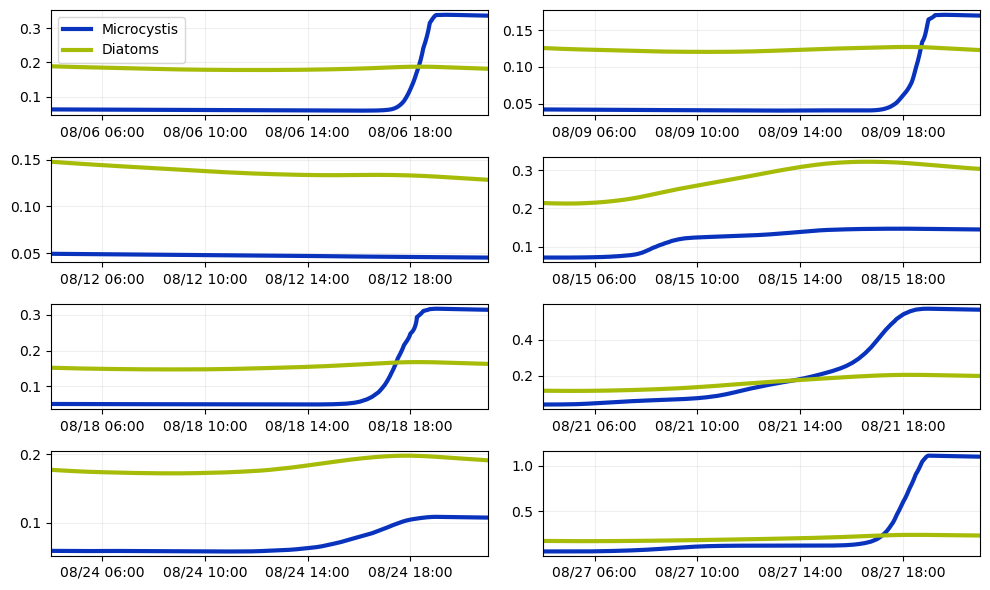

In [4]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(10, 6), sharex=False, sharey=False)
axs = axs.flatten()

for i,d in enumerate(range(6,28,3)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    mc      = ds['algae1'].sum(dim="z")
    diatom = ds['algae2'].sum(dim="z")
    axs[i].plot(time[0:-1], mc[0:-1], label='Microcystis', color="#0933BC", linewidth=3) 
    axs[i].plot(time[0:-1], diatom[0:-1], label='Diatoms', color='#A6BC09', linewidth=3) 
    axs[i].grid(alpha=0.2)
    format_date_ax(axs[i])
    axs[i].set_xlim(time[0], time[-1])
axs[0].legend(loc='upper left', fontsize=10)

plt.tight_layout()
fig.savefig("plots/mc_diatom_time_series.png", dpi=300, bbox_inches='tight')


/tmp/ipykernel_1241950/1892461101.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 0.35)
/tmp/ipykernel_1241950/1892461101.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1.2)


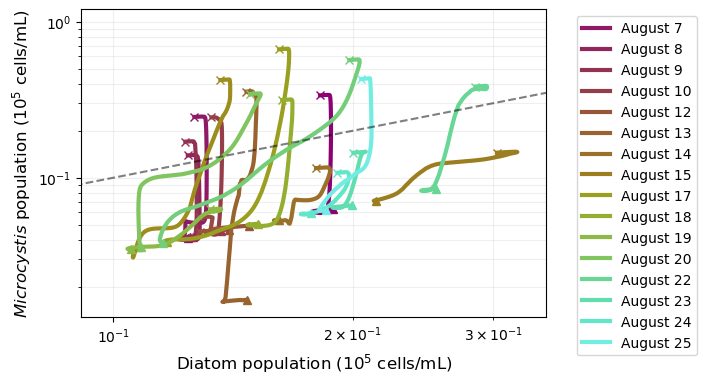

In [20]:
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()

# range(6,28,1)
for i,d in enumerate(range(6, 26)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    mc      = ds['algae1'][0:-1].sum(dim="z")
    diatom = ds['algae2'][0:-1].sum(dim="z")
    c = cmc.hawaii((d-6)/21)
    ax.plot(diatom[0], mc[0], '^', color=c, linewidth=3) 
    ax.plot(diatom[-1], mc[-1], 'x', color=c, linewidth=3) 

    if i%5 == 0:
        ax.plot(diatom[::50], mc[::50], '-', color=c, linewidth=3) 
    else:
        ax.plot(diatom[::50], mc[::50], '-', color=c, linewidth=3, label="August %d" % d)
        # ax.plot
    # axs[i].grid(alpha=0.2)

ax.plot([0, 1.5], [0, 1.5], 'k--', alpha=0.5)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("Diatom population (10$^5$ cells/mL)", fontsize=12)
ax.set_ylabel("$Microcystis$ population (10$^5$ cells/mL)", fontsize=12)
ax.set_xlim(0, 0.35)
ax.set_ylim(0, 1.2)
ax.grid(alpha=0.2, which='both')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
# fig.savefig("plots/mc_diatom_scatter.png", dpi=300, bbox_inches='tight')


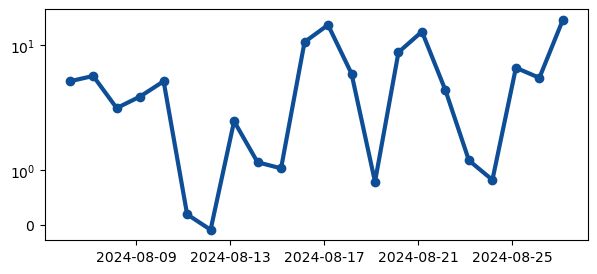

In [6]:
fig = plt.figure(figsize=(7, 3))
ax = plt.gca()

p_d = []
p_m = []
t = [] 
for i,d in enumerate(range(6,28,1)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    mc      = (ds['algae1'][-2].sum(dim="z")  - ds['algae1'][0].sum(dim="z"))/ ds['algae1'][0].sum(dim="z")
    diatom = (ds['algae2'][-2].sum(dim="z")  - ds['algae2'][0].sum(dim="z"))/ ds['algae2'][0].sum(dim="z")
    p_d.append(diatom)
    p_m.append(mc)
    t.append(time[0])
# c = cmo.cm.haline((d-6)/21)
# ax.plot(t, p_d,'-o', color=cmo.cm.haline(0.8), linewidth=3)
ax.plot(t, p_m,'-o', color=cmo.cm.haline(0.2), linewidth=3)
#, width=0.4) 
# c = cmo.cm.thermal((d-6)/21)
    # ax.bar(d, mc, color=c, linewidth=3, width=0.4) 

#     if i%2 == 0:
#         ax.plot(diatom[::50], mc[::50], '-', color=c, linewidth=3) 
#     else:
#         ax.plot(diatom[::50], mc[::50], '-', color=c, linewidth=3, label="August %d" % d)
#     # axs[i].grid(alpha=0.2)

# ax.plot([0, 1.5], [0, 1.5], 'k--', alpha=0.5)
ax.set_yscale('symlog')
# ax.set_xscale('log')
# ax.set_xlim(0, 0.35)
# ax.set_ylim(0, 1.2)
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)


In [34]:
# Time DWL starts developing

# fig = plt.figure(figsize=(9, 4))
# ax = fig.add_subplot(111)


for strength in [1.0]: #np.linspace(0.8, 1.2, 6):
    # fig = plt.figure(figsize=(6, 4))
    # ax = plt.gca()

    interesting_days = [6, 8, 9, 12, 15, 17, 19, 21, 22, 26]
    total_days = range(6, 28)

    start_hour = [] 
    durations = [] 
    diatoms_g = []
    mc_g = [] 


    for i,d in enumerate(total_days):
        # print(d)
        ds = guess["%02d" % (d)]
        m0 = ds.gamma1.sum(dim="t").sum(dim="z")
        d0 = ds.gamma2.sum(dim="t").sum(dim="z")
        mc      = (ds['algae1'][-2].sum(dim="z")  - ds['algae1'][0].sum(dim="z"))/ ds['algae1'][0].sum(dim="z")
        diatom = (ds['algae2'][-2].sum(dim="z")  - ds['algae2'][0].sum(dim="z"))/ ds['algae2'][0].sum(dim="z")
        mc_g.append(m0)
        diatoms_g.append(d0)

        time = Dates[ds.t.values]

        growth0 = ds.gamma1.argmax(dim="z")
        depths = ds.gamma1.z.values[growth0]
        depths[depths==5.95] = np.nan


        x, mixed_d, mask = get_dwl(d, time, strength)
        x0 = pd.to_datetime(x[mask])

        try: 
            start = x0[0].hour  + x0[0].minute/60
            hour = start_hour.append(start)
            breakdown = x0[-1].hour  + x0[-1].minute/60
            print(x0)
            duration = breakdown - start
        except:
            start = np.nan
            duration = 0
        durations.append(duration)

            # duration.append(breakdown)
        # ax.plot(duration, diatom.values, 'o', color=cmc.hawaii(i/21), label="August %d" % d)#, label="Diatoms")
        # ax.plot(duration, mc.values, '^', color=cmc.hawaii(i/21)) #, label="August %d" % d)#, label="Diatoms")

        # ax.plot(duration, mc, 'ro')#, label="Diatoms")
        # ax.plot(duration, d0/duration, 'ko')#, label="$Microcystis$")

    # ax.plot([], [], 'ro', label="% growth Diatoms")
    # ax.plot([], [], 'ko', label="% growth $Microcystis$")
    # ax.set_yscale('symlog')
    # ax.set_xscale('log')
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    # ax.set_xlabel("Normalized diatom growth [-]")
    # ax.set_ylabel("Normalized $Microcystis$ growth [-]")
    # # ax.set_xlabel()
    
    # ax.set_title("strength = %.1f" % strength)

diatoms_g = np.array(diatoms_g)
durations = np.array(durations)

# plt.show()

DatetimeIndex(['2024-08-06 09:30:00', '2024-08-06 10:00:00',
               '2024-08-06 10:15:00', '2024-08-06 10:45:00',
               '2024-08-06 11:00:00', '2024-08-06 11:30:00',
               '2024-08-06 11:45:00', '2024-08-06 12:00:00',
               '2024-08-06 12:45:00', '2024-08-06 13:00:00',
               '2024-08-06 14:15:00', '2024-08-06 14:30:00',
               '2024-08-06 14:45:00', '2024-08-06 15:30:00',
               '2024-08-06 16:15:00', '2024-08-06 16:30:00',
               '2024-08-06 17:30:00', '2024-08-06 17:45:00',
               '2024-08-06 18:30:00'],
              dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2024-08-07 09:30:00', '2024-08-07 10:00:00',
               '2024-08-07 10:15:00', '2024-08-07 10:30:00',
               '2024-08-07 11:15:00', '2024-08-07 11:30:00',
               '2024-08-07 11:45:00', '2024-08-07 12:30:00',
               '2024-08-07 13:00:00', '2024-08-07 13:15:00',
               '2024-08-07 13:45:00', '2024-08-07 14:30:00

<>:45: SyntaxWarning: invalid escape sequence '\i'
<>:46: SyntaxWarning: invalid escape sequence '\i'
<>:45: SyntaxWarning: invalid escape sequence '\i'
<>:46: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_50346/2472051218.py:45: SyntaxWarning: invalid escape sequence '\i'
  ax.set_xlabel("$\int$ Microcystis growth $\cdot$  C", fontsize=10)
/tmp/ipykernel_50346/2472051218.py:46: SyntaxWarning: invalid escape sequence '\i'
  ax.set_ylabel("$\int$ Diatom growth $\cdot$ C", fontsize=10)


0 2
1 2
2 0
3 3
4 4
5 4
6 9
7 11
8 9
9 3
10 3
11 0


/global/homes/s/siennaw/.conda/envs/jup_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/s/siennaw/.conda/envs/jup_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


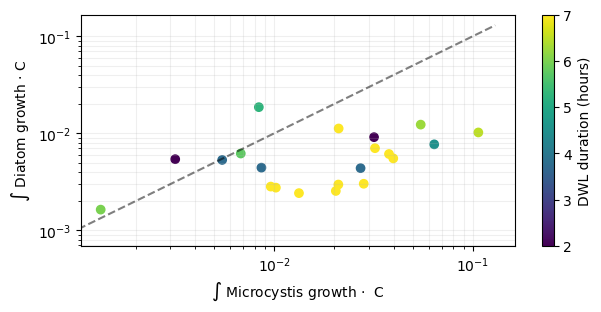

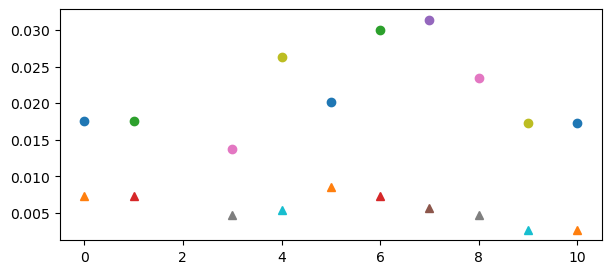

In [51]:
# Look at growth * concentration

strength = 1

durations = [] 
diatoms_g = []
mc_g = [] 


for i,d in enumerate(total_days):
    ds = guess["%02d" % (d)]
    m0 = (ds.gamma1 * ds['algae1']).sum(dim="t").sum(dim="z")
    d0 = (ds.gamma2 * ds['algae2']).sum(dim="t").sum(dim="z")
    mc_g.append(m0)
    diatoms_g.append(d0)

    time = Dates[ds.t.values]

    x, mixed_d, mask = get_dwl(d, time, strength)
    x0 = pd.to_datetime(x[mask])

    try: 
        start = x0[0].hour  + x0[0].minute/60
        hour = start_hour.append(start)
        breakdown = x0[-1].hour  + x0[-1].minute/60
        duration = breakdown - start
    except:
        start = np.nan
        duration = 0
    durations.append(duration)


mc_g = np.array(mc_g)
diatoms_g = np.array(diatoms_g)
durations = np.array(durations)

fig = plt.figure(figsize=(7, 3))
ax = plt.gca()
h= ax.scatter(mc_g, diatoms_g, c=durations, vmin=2, vmax=7)
plt.colorbar(h, label='DWL duration (hours)')
ax.plot([0, 0.13], [0, 0.13], 'k--', alpha=0.5)
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(alpha=0.2, which='both')
ax.set_xlabel("$\int$ Microcystis growth $\cdot$  C", fontsize=10)
ax.set_ylabel("$\int$ Diatom growth $\cdot$ C", fontsize=10)


fig = plt.figure(figsize=(7, 3))
ax = plt.gca()
for co in range(0, 12): 
    index = (durations<(co+1.2)) & (durations>(co-1.2))
    av = np.mean(mc_g[index]) 
    av2 = np.mean(diatoms_g[index])
    print(co, sum(index))
    ax.plot(co, av, 'o')
    ax.plot(co, av2, '^')



/global/homes/s/siennaw/.conda/envs/jup_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/s/siennaw/.conda/envs/jup_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


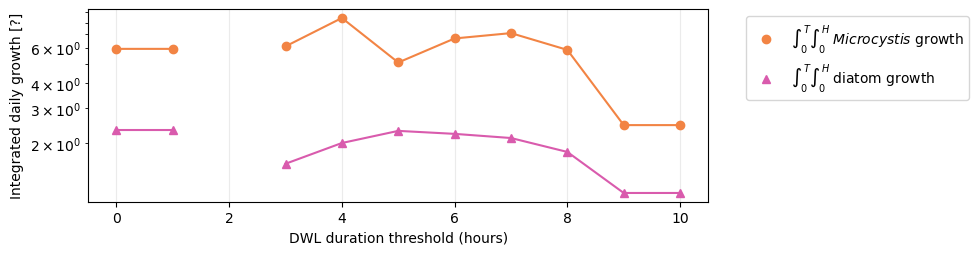

In [8]:
mc_g = np.array(mc_g)
fig = plt.figure(figsize=(8,2.5)) 
ax = plt.gca()

yd = [] 
ym = [] 
for co in range(0, 12): 
    index = (durations<(co+1.2)) & (durations>(co-1.2))
    av = np.mean(mc_g[index]) 
    av2 = np.mean(diatoms_g[index])

    yd.append(av2)
    ym.append(av)

ax.plot(range(0, 12), ym, '-o', color="#F28444")
ax.plot(range(0, 12), yd, '-^', color="#D95BAD")

ax.plot([], [], 'o', color="#F28444", label=r"$\int_0^T \int_0^H$ $Microcystis$ growth")
ax.plot([], [], '^', color="#D95BAD", label=r"$\int_0^T \int_0^H$ diatom growth")


ax.grid(alpha=0.25)
ax.set_yscale('log')
ax.set_xlabel("DWL duration threshold (hours)")
ax.set_ylabel("Integrated daily growth [?]")

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
fig.savefig("plots/mc_diatom_integrated_growth.png", dpi=300, bbox_inches='tight')


[array(0.00965149), array(0.01323767), array(0.01249542), array(0.0112051), array(0.01097703), array(0.00734971), array(0.00402967), array(0.01140624), array(0.01930952), array(0.03170936), array(0.02617221), array(0.03222488), array(0.01642058), array(0.02582225), array(0.03119941), array(0.04344429), array(0.01992436), array(0.01315305), array(0.01704151), array(0.01840824), array(0.03503423), array(0.028281)] [np.float64(0.026751452348715867), np.float64(0.03435968410975265), np.float64(0.019493404127997663), np.float64(0.026340189831604202), np.float64(0.029789329776645796), np.float64(0.00501953133710544), np.float64(9.170276135425435e-05), np.float64(0.02180723000129647), np.float64(0.018181684928419074), np.float64(0.02373049090591067), np.float64(0.11893807954089756), np.float64(0.15140395715507202), np.float64(0.09277011789646793), np.float64(0.028804702327691705), np.float64(0.1207662492460621), np.float64(0.14028925362195035), np.float64(0.08712500979477257), np.float64(0.04

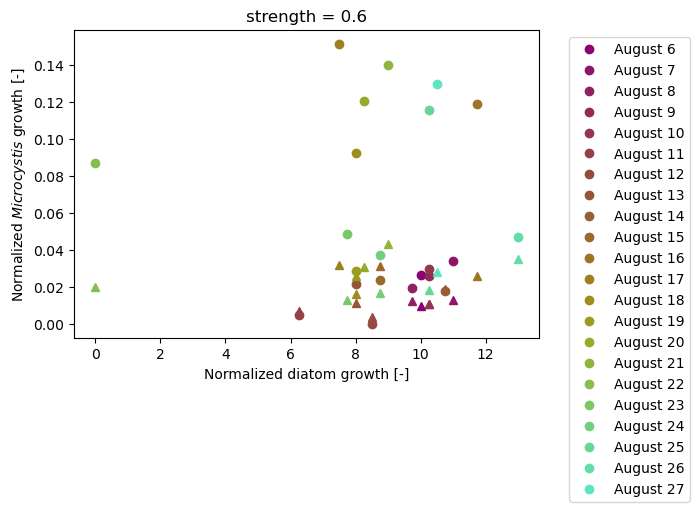

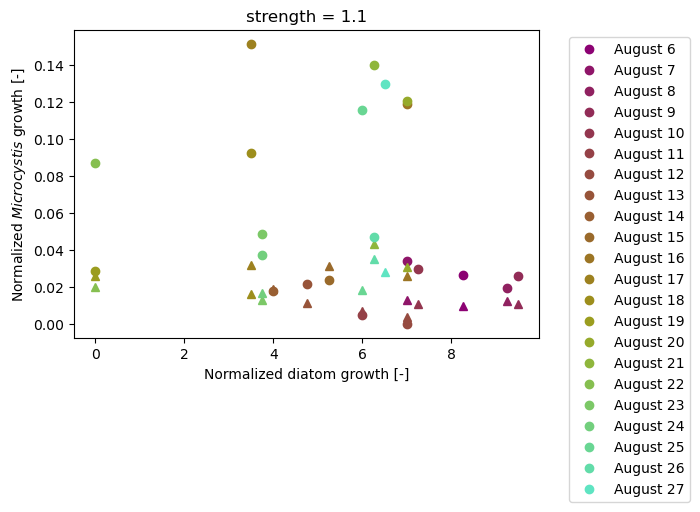

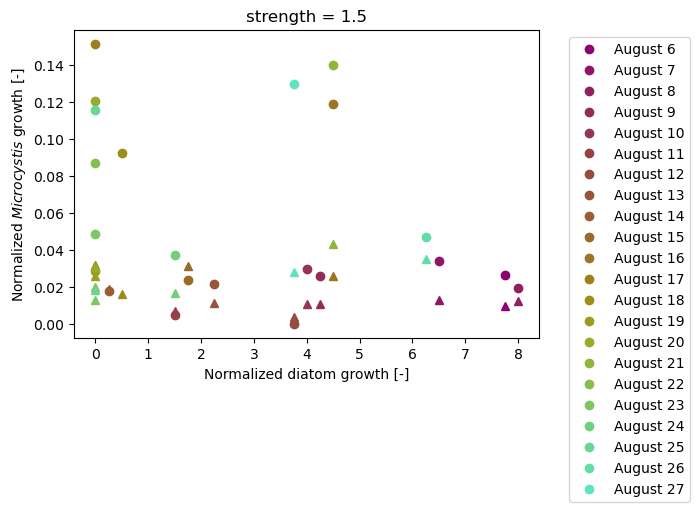

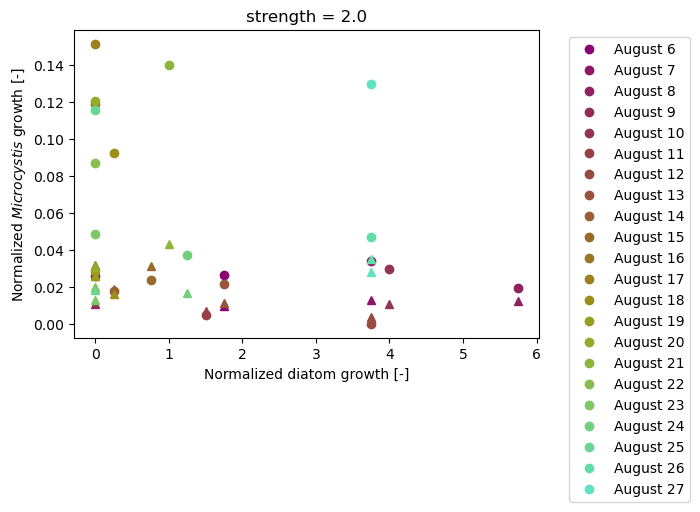

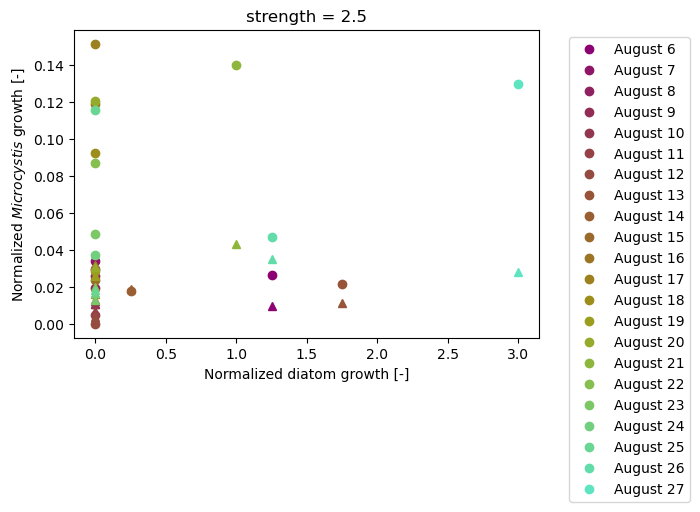

In [9]:
# Time DWL starts developing

# fig = plt.figure(figsize=(9, 4))
# ax = fig.add_subplot(111)

import sklearn as skl 
for strength in np.linspace(0.6, 2.5, 5):
    fig = plt.figure(figsize=(6, 4))
    ax = plt.gca()

    interesting_days = [6, 8, 9, 12, 15, 17, 19, 21, 22, 26]
    total_days = range(6, 28)

    start_hour = [] 
    duration = [] 

    gm = []
    gd = []

    for i,d in enumerate(total_days):
        # print(d)
        ds = guess["%02d" % (d)]
        m0 = ds.gamma1.mean(dim="t").mean(dim="z") * 3600
        d0 = ds.gamma2.mean(dim="t").mean(dim="z") * 3600


        time = Dates[ds.t.values]

        growth0 = ds.gamma1.argmax(dim="z")
        depths = ds.gamma1.z.values[growth0]
        depths[depths==5.95] = np.nan


        x, mixed_d, mask = get_dwl(d, time, strength)
        x0 = pd.to_datetime(x[mask])

        try: 
            start = x0[0].hour  + x0[0].minute/60
            hour = start_hour.append(start)
            breakdown = x0[-1].hour  + x0[-1].minute/60
            duration = breakdown - start
        except:
            start = np.nan
            duration = 0
        gd.append(d0.values)
        gm.append(m0.values*1)
        
        ax.plot(duration , m0, 'o', color=cmc.hawaii(i/25), label="August %d" % d)#, label="Diatoms")
        ax.plot(duration , d0, '^', color=cmc.hawaii(i/25))#, label="$Microcystis$")
    
    
    print(gd, gm)
    r2 = skl.metrics.r2_score(gd, gm)
    print(np.corrcoef(gd, gm)) 
    print(r2)
    # Look at R^2
   

    # ax.plot([], [], 'ro', label="% growth Diatoms")
    # ax.plot([], [], 'ko', label="% growth $Microcystis$")
    # ax.set_yscale('log')
    # ax.set_xscale('log')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.set_xlabel("Normalized diatom growth [-]")
    ax.set_ylabel("Normalized $Microcystis$ growth [-]")
    # ax.set_xlabel()
    
    ax.set_title("strength = %.1f" % strength)



In [10]:

# ax3.plot(d, kz, 'o', color=cmo.cm.haline_r(i/20))
# axs[1].plot(total_days, d1g, '-^', color='#8FBF26', label="average diatom growth rate", linewidth=3, alpha=0.9)
# axs[1].plot(total_days, m1g, '-x', color='#D69220', label="average $Microcystis$ growth rate", linewidth=3, alpha=0.9)
    
# # axs[0].plot(total_days, start_hour, '-o', color="#559BD9", linewidth=3, alpha=0.9)
# axs[0].plot(total_days, duration, '-o', color="#898C26", linewidth=3, alpha=0.9)
# ax3.legend()
# axs[0].set_ylabel("Hour of DWL formation")
# axs[0].xaxis.set_ticks(total_days)
# axs[0].set_xlim(6, 27)

# axs[1].set_ylim(0, 15)
# ax3.set_yscale('log')

# axs[0].set_ylabel("Hour of DWL formation")
# axs[1].set_ylabel("Duration of DWL (hours)")
# for ax in axs:
#     ax.grid(alpha=0.3)
#     ax.legend()

# axs[1].set_xlabel("Day in August")
